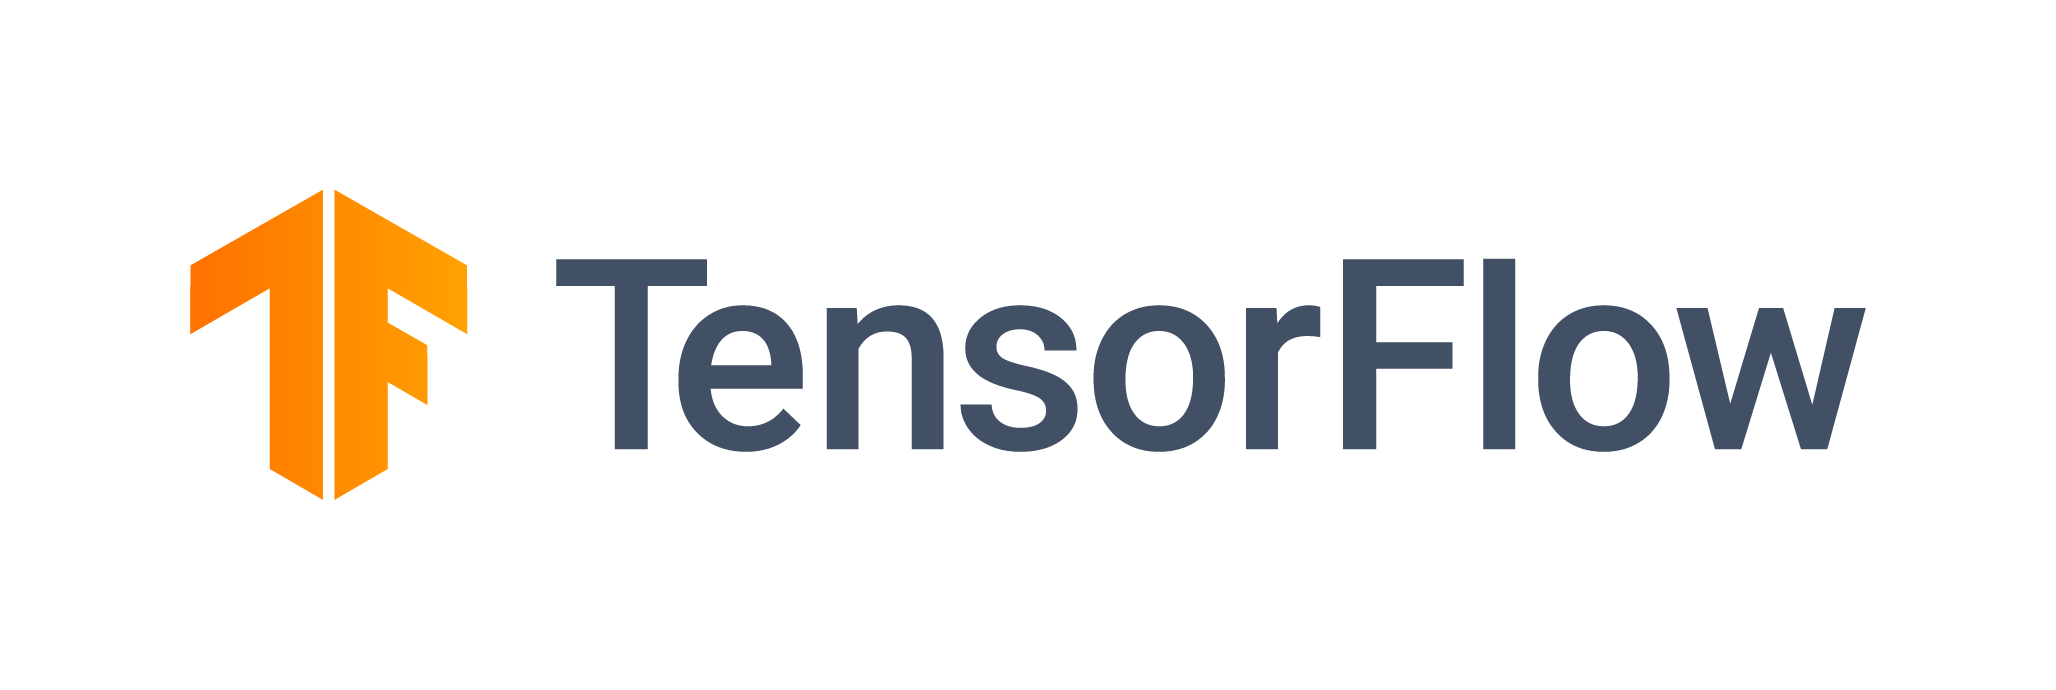

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Make the result reproducible
tf.keras.utils.set_random_seed(42)
# TensorFlow, Scikit-Learn, and most Machine Learning libraries work better
# with NumPy arrays because they are faster, more memory efficient, and
# support mathematical operations directly.

# tf.keras.utils.set_random_seed(42) : Making the results reproducible. Neural-network parameters usually begin with random values.
# For example, the model might initially choose: Weight = 0.73, Bias = 0
# If you run the program again, it might start with: Weight = -0.25, Bias = 0
# This can produce slightly different training results each time.
# Setting a random seed tells TensorFlow : Use the same random starting pattern every time this program runs.
# The number 42 is not mathematically special. You could use: 10, 100 etc.



# Training data
X = np.array([1, 2, 3, 4, 5], dtype=np.float32).reshape(-1, 1)
Y = np.array([10, 20, 30, 40, 50], dtype=np.float32).reshape(-1, 1)
# np.array([1, 2, 3, 4, 5]) : creating numpy array -> [1, 2, 3, 4, 5]
# dtype=np.float32 : This converts the numbers into 32-bit decimal numbers -> [1.0, 2.0, 3.0, 4.0, 5.0]
# You can check the data type using : print(X.dtype) -> float32 (Forces every value to be stored as a 32-bit floating point number.)
# Before reshape it looks like this : [1. 2. 3. 4. 5.], Shape : (5,), Means 5 values in a single dimension.
# After reshape(-1,1) : 
# [[1.]
# [2.]
# [3.]
# [4.]
# [5.]]
# Shape : (5,1), Meaning : 5 rows and 1 column
# Why "-1"? : "-1" tells NumPy : "You automatically calculate how many rows are needed."
# Since we have 5 values and want 1 column : Result: 5 rows × 1 column
# why .reshape(-1, 1)
# Before [1,2,3,4,5], shape (5,) -> meaning 5 values in 1 dimension
# After 
# [[1]
 # [2]
 # [3]
 # [4]
 # [5]], shape (5, 1) -> meaning 5 rows 1 column
# Why use it? TensorFlow expects data in the format : (Number of Records, Number of Features)
# actual meaning of .reshape(-1, 1) is 
                                    # 1 = I want 1 column
                                    # -1 = NumPy automatically calculates the number of rows
# Trick to remember -->> "Make the data vertical (one column) and automatically figure out how many rows are needed."




# Create the model
model = keras.Sequential([keras.Input(shape=(1,)),keras.layers.Dense(1)])

# keras.Sequential(...) means : A Sequential model means that the layers are arranged one after another.
# for example : Input → Layer 1 → Layer 2 → Output
# our model has only one processing layer : Input → Dense layer → Prediction
# keras.Input(shape=(1,)) : This tells TensorFlow,Each training sample contains one input feature.
# our samples are:
# [1]
# [2]
# [3]
# [4]
# [5]
# Every sample contains only one number. Therefore: shape=(1,) The comma is important. In Python, this: (1,)
# represents a tuple containing one item.
# keras.layers.Dense(1) : Creating the Dense layer
# A Dense layer performs a mathematical calculation : Output = Input × Weight + Bias
# Because we wrote : Dense(1) -->> the layer has one output neuron.
# For one input and one output, the layer learns: One weight, One bias
# For example, during training, it may learn : Weight = 9.99, Bias = 0.03
# Its formula becomes : Y = 9.99 × X + 0.03
# The ideal formula is : Y = 10 × X + 0


# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.05),
    loss="mse",
    metrics=["mae"])

# Compiling means configuring how the model will learn.
# You tell TensorFlow three important things:
                                            # Which optimizer to use
                                            # Which loss function to use
                                            # Which additional measurements to display
# optimizer=keras.optimizers.Adam(learning_rate=0.05) : The optimizer updates the model's weight and bias.
# Imagine that the model currently has: Weight = 2, Bias = 1
# For X = 5, the prediction is : Prediction = 2 × 5 + 1, Prediction = 11 (But the correct answer is: 50)
# The optimizer sees that the prediction is far from the correct answer and adjusts the weight and bias.
# For example: 
            # Old weight = 2
            # New weight = 2.5
# It repeats this process many times. "Adam" is the name of the optimization algorithm.
# learning_rate=0.05 : The learning rate controls how large each adjustment is.
# Think of the model as walking toward the correct answer.
# Very small learning rate : 0.00001 (The model takes extremely small steps and may learn very slowly.)
# Moderate learning rate : 0.05 (The model takes larger steps and may reach the answer faster.)
# Very large learning rate : 10 (The model may jump over the correct answer and become unstable.)
# Here we are using : 0.05
# loss="mse" : Loss function, mse means Mean Squared Error. It measures how different the predictions are from the correct answers.
# The basic formula is : MSE = Average of (Actual value - Predicted value)²
# Suppose : Actual values = [10, 20] and Predicted values = [8, 23]
# Error : 10 - 8  = 2 and 20 - 23 = -3
# Squared errors : 2²  = 4 and -3² = 9
# Average : MSE = (4 + 9) / 2 so the final MSE = 6.5 (The model tries to make the loss smaller)
# ----------------------------------------------------
# Large loss = predictions are far from actual values
# Small loss = predictions are close to actual values
# Zero loss  = predictions perfectly match actual values
# -----------------------------------------------------
# metrics=["mae"] : mae means Mean Absolute Error.
# It calculates : MAE = Average of |Actual value - Predicted value|
# Using the same example: 
                        # Actual values    = [10, 20]
                        # Predicted values = [8, 23]

# Absolute error:
                        # |10 - 8|  = 2
                        # |20 - 23| = 3
# Average:
                        # MAE = (2 + 3) / 2
                        # MAE = 2.5
# MAE is often easier to understand because it remains in the same unit as the output.
# --------------------------------------------------------
# Difference between loss and metric
# MSE = used by the optimizer to train the model
# MAE = used to help you understand model performance
# The optimizer directly tries to reduce the MSE loss.





# Save training information inside history
history = model.fit(X,Y,epochs=2000,verbose=0) # This line trains the model.

# model.fit(...) : fit means, Learn the relationship between X and Y.
# TensorFlow receives : 
                        # Input X
                        # Expected output Y
# It generates predictions, calculates errors, and updates the weight and bias.
# epochs=1000 : One epoch means: The model sees the entire training dataset one time.
# We have five training examples.
# In one epoch, the model processes:
                        # 1 → 10
                        # 2 → 20
                        # 3 → 30
                        # 4 → 40
                        # 5 → 50

# With : epochs=1000 : the model sees the complete dataset 1,000 times.
# The process looks like:
                        # Epoch 1:   predict, calculate errors, update parameters
                        # Epoch 2:   predict again, calculate errors, update parameters
                        # Epoch 3:   repeat
                        # ...
                        # Epoch 1000: final update
# verbose=0 : This controls what TensorFlow displays during training.
# verbose=0 → show nothing
# verbose=1 → show progress bars
# verbose=2 → show one line per epoch

# For example, model.fit(X, Y, epochs=10, verbose=1) 
# may display training progress for each epoch.

# Because we trained for 1,000 epochs:
# history.history["loss"] contains 1,000 loss values
# history.history["mae"] contains


# --------------------------------------------------
# 1. MODEL STRUCTURE AND PARAMETER COUNT
# --------------------------------------------------

print("\n========== MODEL SUMMARY ==========")
model.summary() 
# This displays the model structure.

# --------------------------------------------------
# 2. TRAINING HISTORY
# --------------------------------------------------

print("\n========== AVAILABLE HISTORY KEYS ==========")
print(history.history.keys())

# It may look like:
# {
#     "loss": [value1, value2, value3, ...],
#     "mae": [value1, value2, value3, ...]
# }
# .keys() returns the available names: dict_keys(['loss', 'mae'])

print("\n========== LOSS FROM EVERY EPOCH ==========")
for epoch, loss_value in enumerate(history.history["loss"], start=1):
    print(f"Epoch {epoch:4d}: Loss = {loss_value:.6f}")

print("\n========== FIRST EPOCH LOSS ==========")
print(history.history["loss"][0]) #[0] means the first element of the list.

print("\n========== FINAL EPOCH LOSS ==========")
print(history.history["loss"][-1]) #[-1] means the last element.

print("\n========== FINAL MAE ==========")
print(history.history["mae"][-1]) #This retrieves the last MAE value.

# --------------------------------------------------
# 3. EVALUATE MODEL
# --------------------------------------------------

loss, mae = model.evaluate(X, Y, verbose=0)
# This tests the trained model on X and Y.
# TensorFlow does the following:
                        # Makes predictions for X
                        # Compares predictions with Y
                        # Calculates MSE
                        # Calculates MAE
                        # Returns both values
# Because my model was compiled with:
                        # loss="mse"
                        # metrics=["mae"]
# model.evaluate() returns two values :
                        # MSE loss
                        # MAE


print("\n========== MODEL EVALUATION ==========")
print(f"MSE Loss : {loss}")
print(f"MAE      : {mae}")

# --------------------------------------------------
# 4. LEARNED WEIGHT AND BIAS
# --------------------------------------------------

weight, bias = model.layers[0].get_weights()

# model.layers[0]
            # This contains the model's layers.
            # Our model has one Dense layer.
            # [0] means, Python starts counting from zero. (so the layers[0] = first layer)

# .get_weights()
            # This returns the learned parameters of the Dense layer.
                # it returns:
                            # Weight array
                            # Bias array
            # we store them as : weight, bias
# they may looks like :
                    # weight = [[9.99]]
                    # bias = [0.03]




print("\n========== LEARNED PARAMETERS ==========")
print(f"Learned weight: {weight[0]}")
print(f"Learned bias: {bias}")

print("\n========== LEARNED FORMULA ==========")
print(f"Y = ({weight[0]} x X) + ({bias})")

# --------------------------------------------------
# 5. ALL MODEL WEIGHTS
# --------------------------------------------------

print("\n========== ALL MODEL WEIGHTS ==========")

for variable in model.weights:
    print(f"Name  : {variable.name}")
    print(f"Shape : {variable.shape}")
    print(f"Value :\n{variable.numpy()}")
    print("-" * 50)

# --------------------------------------------------
# 6. TRAINABLE PARAMETERS
# --------------------------------------------------

print("\n========== TRAINABLE VARIABLES ==========")

for variable in model.trainable_variables:
    print(f"Name  : {variable.name}")
    print(f"Shape : {variable.shape}")
    print(f"Value :\n{variable.numpy()}")
    print("-" * 50)

# --------------------------------------------------
# 7. OPTIMIZER INFORMATION
# --------------------------------------------------

print("\n========== OPTIMIZER INFORMATION ==========")
print(f"Optimizer     : {model.optimizer.name}")
print(f"Learning rate: {model.optimizer.learning_rate.numpy()}")
print(f"Iterations    : {model.optimizer.iterations.numpy()}")

print("\n========== OPTIMIZER CONFIGURATION ==========")

optimizer_config = model.optimizer.get_config()

for parameter_name, parameter_value in optimizer_config.items():
    print(f"{parameter_name}: {parameter_value}")

# --------------------------------------------------
# 8. MAKE PREDICTIONS
# --------------------------------------------------

new_X = np.array([[6], [7], [8]], dtype=np.float32)

predictions = model.predict(new_X, verbose=0)

print("\n========== PREDICTIONS ==========")

for input_value, predicted_value in zip(new_X, predictions):
    print(
        f"X = {input_value} | "
        f"Predicted Y = {predicted_value} | "
        f"Expected Y = {input_value[0] * 10}"
    )

# --------------------------------------------------
# 9. MANUAL PREDICTION CHECK
# --------------------------------------------------

manual_predictions = (new_X * weight[0][0]) + bias[0]

print("\n========== MANUAL PREDICTIONS ==========")
print(manual_predictions)

# --------------------------------------------------
# 10. SHOW LOSS AT SELECTED EPOCHS
# --------------------------------------------------

print("\n========== LOSS PROGRESS ==========")

selected_epochs = [1, 10, 50, 100, 200, 500, 1000, 1001, 1010, 1050, 1100, 1200, 1500, 2000]

for epoch in selected_epochs:
    epoch_loss = history.history["loss"][epoch - 1]
    print(f"Epoch {epoch:4d}: Loss = {epoch_loss}")


========== MODEL SUMMARY ==========


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (36.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6 (28.00 B)


========== AVAILABLE HISTORY KEYS ==========
dict_keys(['loss', 'mae'])

========== LOSS FROM EVERY EPOCH ==========
Epoch    1: Loss = 843.958801
Epoch    2: Loss = 831.741028
Epoch    3: Loss = 819.615601
Epoch    4: Loss = 807.584106
Epoch    5: Loss = 795.648193
Epoch    6: Loss = 783.809204
Epoch    7: Loss = 772.068542
Epoch    8: Loss = 760.427612
Epoch    9: Loss = 748.887817
Epoch   10: Loss = 737.450256
Epoch   11: Loss = 726.116150
Epoch   12: Loss = 714.886719
Epoch   13: Loss = 703.763062
Epoch   14: Loss = 692.746216
Epoch   15: Loss = 681.837036
Epoch   16: Loss = 671.036438
Epoch   17: Loss = 660.345093
Epoch   18: Loss = 649.763916
Epoch   19: Loss = 639.293518
Epoch   20: Loss = 628.934509
Epoch   21: Loss = 618.687378
Epoch   22: Loss = 608.552612
Epoch   23: Loss = 598.530579
Epoch   24: Loss = 588.621704
Epoch   25: Loss = 578.826050
Epoch   26: Loss = 569.143921
Epoch   27: Loss = 559.575439
Epoch   28: Loss = 550.120728
Epoch   29: Loss = 540.779724
Epoch   30: 

## Tensorflow - 1
# How a Single-Neuron Model Learns `Y = 10X`: Complete Mathematical Explanation

> This document explains the model entirely through mathematics. It does not focus on Python, TensorFlow, programming syntax, or computer operations.

---

## 1. The Mathematical Problem

We have five examples:

$$
\begin{aligned}
1 &\rightarrow 10\\
2 &\rightarrow 20\\
3 &\rightarrow 30\\
4 &\rightarrow 40\\
5 &\rightarrow 50
\end{aligned}
$$

We can represent the input values as:

$$
X=
\begin{bmatrix}
1\\
2\\
3\\
4\\
5
\end{bmatrix}
$$

The corresponding correct output values are:

$$
Y=
\begin{bmatrix}
10\\
20\\
30\\
40\\
50
\end{bmatrix}
$$

By looking at the examples, we can see that the actual relationship is:

$$
Y=10X
$$

For example:

$$
\begin{aligned}
10 &= 10(1)\\
20 &= 10(2)\\
30 &= 10(3)\\
40 &= 10(4)\\
50 &= 10(5)
\end{aligned}
$$

But the model does not initially know that the multiplier is `10`. The model must discover that value through repeated mathematical calculations.

---

## 2. The Mathematical Model

The model assumes that the relationship has this general form:

$$
\boxed{\hat{Y}=wX+b}
$$

Where:

- $X$ is the input.
- $\hat{Y}$ is the model's predicted output.
- $w$ is the **weight**.
- $b$ is the **bias**.
- The hat over $\hat{Y}$ means **predicted value**.

The model must learn the correct values of $w$ and $b$.

For this dataset, the perfect values are:

$$
w=10
$$

and:

$$
b=0
$$

Therefore, the perfect formula is:

$$
\hat{Y}=10X+0
$$

or simply:

$$
\boxed{\hat{Y}=10X}
$$

---

## 3. Why Do We Need a Weight?

The weight controls how strongly the input affects the output.

Consider:

$$
\hat{Y}=wX+b
$$

If:

$$
w=2,\qquad b=0
$$

then:

$$
\hat{Y}=2X
$$

For $X=5$:

$$
\hat{Y}=2(5)=10
$$

If:

$$
w=10,\qquad b=0
$$

then:

$$
\hat{Y}=10X
$$

For $X=5$:

$$
\hat{Y}=10(5)=50
$$

Therefore, increasing the weight increases how quickly the output grows. In this dataset, every input is multiplied by `10`, so the correct weight is:

$$
\boxed{w=10}
$$

---

## 4. Why Do We Need a Bias?

The bias allows the entire line to move upward or downward.

Consider:

$$
\hat{Y}=wX+b
$$

Suppose:

$$
w=10,\qquad b=5
$$

Then:

$$
\hat{Y}=10X+5
$$

For different values of $X$:

$$
\begin{aligned}
X=1 &: \hat{Y}=10(1)+5=15\\
X=2 &: \hat{Y}=10(2)+5=25\\
X=3 &: \hat{Y}=10(3)+5=35
\end{aligned}
$$

The bias added `5` to every prediction. However, the correct outputs are:

$$
10,\ 20,\ 30,\ 40,\ 50
$$

No additional amount is added. Therefore, the ideal bias is:

$$
\boxed{b=0}
$$

---

## 5. The Model Starts with Initial Values

The model does not start with:

$$
w=10,\qquad b=0
$$

That would mean the model already knew the answer.

Instead, the weight usually starts with a small random value. For this mathematical demonstration, suppose the model starts with:

$$
w=1
$$

and:

$$
b=0
$$

The starting formula is:

$$
\hat{Y}=1X+0
$$

or:

$$
\hat{Y}=X
$$

The initial predictions are therefore:

| Input $X$ | Actual $Y$ | Prediction $\hat{Y}$ |
|---:|---:|---:|
| 1 | 10 | 1 |
| 2 | 20 | 2 |
| 3 | 30 | 3 |
| 4 | 40 | 4 |
| 5 | 50 | 5 |

The predictions are far below the correct answers, so the weight must increase.

---

## 6. Finding the Error

For each example, the error is:

$$
\boxed{e_i=\hat{Y}_i-Y_i}
$$

Where:

- $e_i$ is the error for example $i$.
- $\hat{Y}_i$ is the predicted value.
- $Y_i$ is the correct value.

Using the initial predictions:

$$
\begin{aligned}
e_1 &= 1-10=-9\\
e_2 &= 2-20=-18\\
e_3 &= 3-30=-27\\
e_4 &= 4-40=-36\\
e_5 &= 5-50=-45
\end{aligned}
$$

The errors are:

$$
\begin{bmatrix}
-9\\
-18\\
-27\\
-36\\
-45
\end{bmatrix}
$$

The negative errors tell us that the predictions are smaller than the correct answers.

---

## 7. Why We Cannot Simply Add the Errors

If some errors are positive and others are negative, they can cancel each other.

For example:

$$
5+(-5)=0
$$

A total error of zero might suggest there is no mistake, even though both predictions were wrong by `5`.

Therefore, we need a method that prevents positive and negative errors from cancelling each other. One method is to square every error.

---

## 8. Mean Squared Error

The training loss is **Mean Squared Error**, or **MSE**.

The formula is:

$$
\boxed{
\operatorname{MSE}
=
\frac{1}{n}
\sum_{i=1}^{n}
(Y_i-\hat{Y}_i)^2
}
$$

Where:

- $n$ is the number of examples.
- $Y_i$ is the correct value.
- $\hat{Y}_i$ is the predicted value.
- $\sum$ means add all the values.
- Squaring removes negative signs.
- Dividing by $n$ calculates the average.

We have five examples, so:

$$
n=5
$$

The squared errors are:

$$
\begin{aligned}
(-9)^2 &= 81\\
(-18)^2 &= 324\\
(-27)^2 &= 729\\
(-36)^2 &= 1296\\
(-45)^2 &= 2025
\end{aligned}
$$

Add them:

$$
81+324+729+1296+2025=4455
$$

Now divide by the number of examples:

$$
\operatorname{MSE}=\frac{4455}{5}
$$

Therefore:

$$
\boxed{\operatorname{MSE}=891}
$$

This is a high loss because the predictions are far from the correct answers.

---

## 9. Why Do We Square the Errors?

### Reason 1: Negative values become positive

$$
(-9)^2=81
$$

Positive and negative errors therefore do not cancel each other.

### Reason 2: Large mistakes receive a larger penalty

Compare an error of `2` with an error of `10`:

$$
2^2=4
$$

$$
10^2=100
$$

The error of `10` receives a much larger penalty.

### Reason 3: The squared function is differentiable

We can calculate its derivative. The derivative tells the model how the weight and bias should change to reduce the loss.

---

## 10. Mean Absolute Error

**MAE** means **Mean Absolute Error**.

The formula is:

$$
\boxed{
\operatorname{MAE}
=
\frac{1}{n}
\sum_{i=1}^{n}
|Y_i-\hat{Y}_i|
}
$$

The vertical lines mean absolute value. Absolute value removes the negative sign:

$$
|-9|=9
$$

Using our errors:

$$
\begin{aligned}
|-9| &= 9\\
|-18| &= 18\\
|-27| &= 27\\
|-36| &= 36\\
|-45| &= 45
\end{aligned}
$$

Add them:

$$
9+18+27+36+45=135
$$

Divide by `5`:

$$
\operatorname{MAE}=\frac{135}{5}
$$

Therefore:

$$
\boxed{\operatorname{MAE}=27}
$$

This means that, on average, the predictions are `27` units away from the correct answers.

---

## 11. Difference Between MSE and MAE

For the starting model:

$$
\operatorname{MSE}=891
$$

and:

$$
\operatorname{MAE}=27
$$

MSE squares the errors:

$$
\operatorname{MSE}=\text{average of squared errors}
$$

MAE uses the absolute errors:

$$
\operatorname{MAE}=\text{average distance from the correct answers}
$$

MSE is used as the main loss to train this model. MAE is an additional measurement that is often easier for a person to understand.

---

## 12. MSE in Terms of Weight and Bias

The prediction formula is:

$$
\hat{Y}_i=wX_i+b
$$

Substitute that into the MSE formula:

$$
\operatorname{MSE}
=
\frac{1}{n}
\sum_{i=1}^{n}
\left(Y_i-(wX_i+b)\right)^2
$$

It can also be written as:

$$
\boxed{
L(w,b)
=
\frac{1}{n}
\sum_{i=1}^{n}
(wX_i+b-Y_i)^2
}
$$

The letter $L$ represents **loss**. This formula says that the loss depends on $w$ and $b$.

The goal is to find the values of $w$ and $b$ that make the loss as small as possible:

$$
\boxed{\min_{w,b}L(w,b)}
$$

This means:

> Find the weight and bias that minimize the loss.

---

## 13. How Does the Model Know Which Direction to Move?

The model uses **derivatives**.

A derivative tells us:

- Whether increasing a value will increase or decrease the loss.
- How strongly the loss will change.
- Which direction should be used to reduce the loss.

The derivative of the loss with respect to the weight is:

$$
\boxed{
\frac{\partial L}{\partial w}
=
\frac{2}{n}
\sum_{i=1}^{n}
X_i(wX_i+b-Y_i)
}
$$

The derivative of the loss with respect to the bias is:

$$
\boxed{
\frac{\partial L}{\partial b}
=
\frac{2}{n}
\sum_{i=1}^{n}
(wX_i+b-Y_i)
}
$$

These derivatives are also called **gradients**.

---

## 14. Calculating the Weight Gradient

Suppose:

$$
w=1,\qquad b=0
$$

The errors using $\hat{Y}-Y$ are:

$$
-9,-18,-27,-36,-45
$$

The weight gradient is:

$$
\frac{\partial L}{\partial w}
=
\frac{2}{5}
\sum_{i=1}^{5}X_i(\hat{Y}_i-Y_i)
$$

Substitute the numbers:

$$
\frac{\partial L}{\partial w}
=
\frac{2}{5}
\left[1(-9)+2(-18)+3(-27)+4(-36)+5(-45)\right]
$$

Calculate each multiplication:

$$
\begin{aligned}
1(-9)&=-9\\
2(-18)&=-36\\
3(-27)&=-81\\
4(-36)&=-144\\
5(-45)&=-225
\end{aligned}
$$

Add them:

$$
-9-36-81-144-225=-495
$$

Multiply by $\frac{2}{5}$:

$$
\frac{\partial L}{\partial w}
=
\frac{2}{5}(-495)
$$

Therefore:

$$
\boxed{\frac{\partial L}{\partial w}=-198}
$$

The gradient is negative. That means the model must increase the weight to reduce the loss.

---

## 15. Calculating the Bias Gradient

The bias gradient is:

$$
\frac{\partial L}{\partial b}
=
\frac{2}{5}
\sum_{i=1}^{5}(\hat{Y}_i-Y_i)
$$

Substitute the errors:

$$
\frac{\partial L}{\partial b}
=
\frac{2}{5}[-9-18-27-36-45]
$$

Add the errors:

$$
-9-18-27-36-45=-135
$$

Therefore:

$$
\frac{\partial L}{\partial b}
=
\frac{2}{5}(-135)
$$

$$
\boxed{\frac{\partial L}{\partial b}=-54}
$$

The bias gradient is also negative, so the bias will initially increase.

---

## 16. Learning Rate

The learning rate is:

$$
\alpha=0.05
$$

The Greek letter $\alpha$, pronounced **alpha**, is commonly used for the learning rate.

The learning rate controls the size of each mathematical update.

A smaller learning rate creates smaller changes:

$$
\alpha=0.0001
$$

A larger learning rate creates larger changes:

$$
\alpha=0.05
$$

If the learning rate is too small, learning may be very slow. If the learning rate is too large, the model may repeatedly move past the best answer.

---

## 17. Basic Gradient Descent Update

In ordinary gradient descent, the update formulas are:

$$
\boxed{
w_{\text{new}}
=
w_{\text{old}}
-
\alpha\frac{\partial L}{\partial w}
}
$$

and:

$$
\boxed{
b_{\text{new}}
=
b_{\text{old}}
-
\alpha\frac{\partial L}{\partial b}
}
$$

The gradient tells us the direction. The learning rate controls the size of the movement.

For example, using:

$$
w_{\text{old}}=1
$$

$$
\alpha=0.001
$$

and:

$$
\frac{\partial L}{\partial w}=-198
$$

we get:

$$
w_{\text{new}}=1-0.001(-198)
$$

A negative multiplied by a negative becomes positive:

$$
w_{\text{new}}=1+0.198
$$

Therefore:

$$
w_{\text{new}}=1.198
$$

The weight increased because the original predictions were too small.

> The example above uses ordinary gradient descent with a learning rate of `0.001` only to make the basic update easy to see. Adam uses a different update calculation, explained next.

---

## 18. What Adam Does Mathematically

Adam keeps track of two things:

1. The recent average of the gradients.
2. The recent average of the squared gradients.

For a parameter such as the weight, let the gradient at training step $t$ be:

$$
g_t
$$

For the first step:

$$
g_1=-198
$$

Adam normally uses two constants:

$$
\beta_1=0.9
$$

and:

$$
\beta_2=0.999
$$

### 18.1 First Moment

The first moment is:

$$
\boxed{
m_t
=
\beta_1m_{t-1}
+
(1-\beta_1)g_t
}
$$

The first moment is similar to a moving average of the gradients.

Initially:

$$
m_0=0
$$

For the first step:

$$
m_1=0.9(0)+0.1(-198)
$$

$$
m_1=-19.8
$$

### 18.2 Second Moment

The second moment is:

$$
\boxed{
v_t
=
\beta_2v_{t-1}
+
(1-\beta_2)g_t^2
}
$$

The second moment tracks the squared gradients.

Initially:

$$
v_0=0
$$

First calculate:

$$
g_1^2=(-198)^2=39204
$$

Then:

$$
v_1=0.999(0)+0.001(39204)
$$

$$
v_1=39.204
$$

---

## 19. Adam Bias Correction

During the first few steps, the moving averages are close to zero because the moving averages started from zero. Adam corrects this effect.

The corrected first moment is:

$$
\boxed{
\hat{m}_t
=
\frac{m_t}{1-\beta_1^t}
}
$$

For the first step:

$$
\hat{m}_1
=
\frac{-19.8}{1-0.9^1}
$$

$$
\hat{m}_1
=
\frac{-19.8}{0.1}
$$

$$
\boxed{\hat{m}_1=-198}
$$

The corrected second moment is:

$$
\boxed{
\hat{v}_t
=
\frac{v_t}{1-\beta_2^t}
}
$$

For the first step:

$$
\hat{v}_1
=
\frac{39.204}{1-0.999^1}
$$

$$
\hat{v}_1
=
\frac{39.204}{0.001}
$$

$$
\boxed{\hat{v}_1=39204}
$$

---

## 20. Adam's Final Update Formula

Adam updates a parameter using:

$$
\boxed{
\theta_t
=
\theta_{t-1}
-
\alpha
\frac{\hat{m}_t}
{\sqrt{\hat{v}_t}+\epsilon}
}
$$

Where:

- $\theta$ represents the parameter, such as weight or bias.
- $\alpha$ is the learning rate.
- $\hat{m}_t$ is the corrected first moment.
- $\hat{v}_t$ is the corrected second moment.
- $\epsilon$ is a tiny number used to avoid division by zero.

For the weight:

$$
w_1
=
1
-
0.05
\frac{-198}{\sqrt{39204}+\epsilon}
$$

Because:

$$
\sqrt{39204}=198
$$

we get approximately:

$$
w_1
=
1
-
0.05\left(\frac{-198}{198}\right)
$$

$$
w_1=1-0.05(-1)
$$

$$
w_1=1+0.05
$$

Therefore:

$$
\boxed{w_1\approx1.05}
$$

Adam similarly updates the bias from approximately:

$$
b_0=0
$$

to:

$$
\boxed{b_1\approx0.05}
$$

After the first update, the new formula is approximately:

$$
\boxed{\hat{Y}=1.05X+0.05}
$$

---

## 21. Checking the New Predictions

Using:

$$
\hat{Y}=1.05X+0.05
$$

we get:

$$
\begin{aligned}
X=1 &: \hat{Y}=1.05(1)+0.05=1.10\\
X=2 &: \hat{Y}=1.05(2)+0.05=2.15\\
X=3 &: \hat{Y}=1.05(3)+0.05=3.20\\
X=4 &: \hat{Y}=1.05(4)+0.05=4.25\\
X=5 &: \hat{Y}=1.05(5)+0.05=5.30
\end{aligned}
$$

The new predictions are:

$$
\begin{bmatrix}
1.10\\
2.15\\
3.20\\
4.25\\
5.30
\end{bmatrix}
$$

These values are still far from the actual answers, but the new values are slightly better than the original predictions.

---

## 22. Calculating the New Loss

The new errors are:

$$
\begin{aligned}
1.10-10&=-8.90\\
2.15-20&=-17.85\\
3.20-30&=-26.80\\
4.25-40&=-35.75\\
5.30-50&=-44.70
\end{aligned}
$$

Square the errors:

$$
\begin{aligned}
(-8.90)^2 &=79.21\\
(-17.85)^2 &=318.6225\\
(-26.80)^2 &=718.24\\
(-35.75)^2 &=1278.0625\\
(-44.70)^2 &=1998.09
\end{aligned}
$$

Add them:

$$
79.21+318.6225+718.24+1278.0625+1998.09=4392.225
$$

Divide by `5`:

$$
\operatorname{MSE}=\frac{4392.225}{5}
$$

$$
\boxed{\operatorname{MSE}=878.445}
$$

The original loss was:

$$
891
$$

The new loss is:

$$
878.445
$$

Therefore:

$$
878.445<891
$$

The loss decreased. This means the mathematical update moved the weight and bias in the correct direction.

---

## 23. What Is One Epoch?

One epoch means the complete set of five examples is used once:

$$
(1,10),\ (2,20),\ (3,30),\ (4,40),\ (5,50)
$$

During one epoch, the general process is:

$$
\boxed{
\text{Predict}
\rightarrow
\text{Calculate errors}
\rightarrow
\text{Calculate loss}
\rightarrow
\text{Calculate gradients}
\rightarrow
\text{Update parameters}
}
$$

This process is repeated for 1,000 epochs:

$$
\text{Epoch }1\rightarrow(w_1,b_1)
$$

$$
\text{Epoch }2\rightarrow(w_2,b_2)
$$

$$
\text{Epoch }3\rightarrow(w_3,b_3)
$$

and eventually:

$$
\text{Epoch }1000\rightarrow(w_{1000},b_{1000})
$$

Ideally:

$$
w_{1000}\approx10
$$

and:

$$
b_{1000}\approx0
$$

---

## 24. Training History

The training history is a mathematical record of the loss after every epoch.

For example:

$$
\begin{aligned}
L_1 &=843.9588\\
L_2 &=831.7410\\
L_3 &=819.6156\\
L_4 &=807.5841\\
&\vdots\\
L_{1000}&\approx0
\end{aligned}
$$

Where $L_t$ means the loss after epoch $t$.

The first-epoch loss is:

$$
\boxed{L_1}
$$

The final-epoch loss is:

$$
\boxed{L_{1000}}
$$

If:

$$
L_{1000}<L_1
$$

then the model improved during training.

---

## 25. Final MAE Example

Suppose the model learns:

$$
w=9.99
$$

and:

$$
b=0.03
$$

The final formula is:

$$
\hat{Y}=9.99X+0.03
$$

The predictions are:

$$
\begin{aligned}
X=1 &: 9.99(1)+0.03=10.02\\
X=2 &: 9.99(2)+0.03=20.01\\
X=3 &: 9.99(3)+0.03=30.00\\
X=4 &: 9.99(4)+0.03=39.99\\
X=5 &: 9.99(5)+0.03=49.98
\end{aligned}
$$

The absolute errors are:

$$
\begin{aligned}
|10-10.02|&=0.02\\
|20-20.01|&=0.01\\
|30-30.00|&=0.00\\
|40-39.99|&=0.01\\
|50-49.98|&=0.02
\end{aligned}
$$

Therefore:

$$
\operatorname{MAE}
=
\frac{0.02+0.01+0+0.01+0.02}{5}
$$

$$
\operatorname{MAE}=\frac{0.06}{5}
$$

$$
\boxed{\operatorname{MAE}=0.012}
$$

This means the predictions are, on average, only `0.012` units away from the correct answers.

---

## 26. Model Structure and Parameter Count

The mathematical model has:

- One input value.
- One output value.
- One weight.
- One bias.

The formula is:

$$
\hat{Y}=wX+b
$$

Therefore, the total number of parameters is:

$$
1\text{ weight}+1\text{ bias}=2\text{ parameters}
$$

Both parameters can change during training:

$$
\boxed{\text{Trainable parameters}=2}
$$

There are no fixed parameters in this simple model:

$$
\boxed{\text{Non-trainable parameters}=0}
$$

---

## 27. Weight Shape

There is one input and one output. The weight connects the single input to the single output:

$$
X\xrightarrow{w}\hat{Y}
$$

Therefore, the weight can be represented as a $1\times1$ matrix:

$$
W=
\begin{bmatrix}
w
\end{bmatrix}
$$

Its dimensions are:

$$
\boxed{1\times1}
$$

---

## 28. Bias Shape

There is one output, so there is one bias:

$$
B=
\begin{bmatrix}
b
\end{bmatrix}
$$

Its size is:

$$
\boxed{1}
$$

For example:

$$
W=
\begin{bmatrix}
9.99
\end{bmatrix}
$$

and:

$$
B=
\begin{bmatrix}
0.03
\end{bmatrix}
$$

---

## 29. Mathematical Evaluation

Evaluation means using the final weight and bias to calculate predictions for the known examples and then calculating MSE and MAE.

The evaluation formulas are:

$$
\boxed{
\operatorname{MSE}
=
\frac{1}{5}
\sum_{i=1}^{5}
(Y_i-\hat{Y}_i)^2
}
$$

and:

$$
\boxed{
\operatorname{MAE}
=
\frac{1}{5}
\sum_{i=1}^{5}
|Y_i-\hat{Y}_i|
}
$$

No weight or bias is changed during evaluation. Evaluation only measures how well the current formula performs.

---

## 30. Learned Formula

When training finishes, suppose the learned values are:

$$
w=9.99
$$

and:

$$
b=0.03
$$

Then the learned formula is:

$$
\boxed{\hat{Y}=9.99X+0.03}
$$

The ideal formula is:

$$
\boxed{Y=10X}
$$

The learned formula is close to the ideal formula. A learned formula does not always need to contain exactly `10` and `0`. Iterative training usually produces approximate values.

---

## 31. Predicting New Values

After learning the weight and bias, we provide new input values:

$$
X_{\text{new}}=
\begin{bmatrix}
6\\
7\\
8
\end{bmatrix}
$$

Suppose:

$$
w=9.99,\qquad b=0.03
$$

### Prediction for 6

$$
\hat{Y}=9.99(6)+0.03
$$

$$
\hat{Y}=59.94+0.03
$$

$$
\boxed{\hat{Y}=59.97}
$$

The expected answer is:

$$
10(6)=60
$$

### Prediction for 7

$$
\hat{Y}=9.99(7)+0.03
$$

$$
\hat{Y}=69.93+0.03
$$

$$
\boxed{\hat{Y}=69.96}
$$

The expected answer is:

$$
10(7)=70
$$

### Prediction for 8

$$
\hat{Y}=9.99(8)+0.03
$$

$$
\hat{Y}=79.92+0.03
$$

$$
\boxed{\hat{Y}=79.95}
$$

The expected answer is:

$$
10(8)=80
$$

---

## 32. Manual Prediction Check

The mathematical model uses:

$$
\hat{Y}=wX+b
$$

Therefore, manually calculating $(X\times w)+b$ must produce the same result.

Using:

$$
w=9.99,\qquad b=0.03
$$

we get:

$$
(6\times9.99)+0.03=59.97
$$

$$
(7\times9.99)+0.03=69.96
$$

$$
(8\times9.99)+0.03=79.95
$$

This manual check shows that a single-neuron model is performing:

$$
\boxed{\text{Multiplication followed by addition}}
$$

---

## 33. Selected Epoch Losses

For 1,000 epochs, we have:

$$
L_1,L_2,L_3,\ldots,L_{1000}
$$

Instead of inspecting every value, selected epochs can be inspected:

$$
L_1,\ L_{10},\ L_{50},\ L_{100},\ L_{200},\ L_{500},\ L_{1000}
$$

An illustrative sequence could look like:

$$
\begin{aligned}
L_1 &=843.9588\\
L_{10} &=737.4502\\
L_{50} &=377.4169\\
L_{100} &=134.5834\\
L_{200} &=20.2554\\
L_{500} &=0.1000\\
L_{1000} &=0.0001
\end{aligned}
$$

The important pattern is:

$$
L_1>L_{10}>L_{50}>L_{100}>L_{200}>L_{500}>L_{1000}
$$

This pattern shows that the loss is decreasing.

> The values above are illustrative. The exact values depend on the starting parameters and the optimizer updates.

---

## 34. Why Epoch Minus One Is Used to Locate a Recorded Loss

Mathematically, epochs are named:

$$
1,2,3,\ldots,1000
$$

In a zero-based recorded sequence, the positions are:

$$
0,1,2,\ldots,999
$$

Therefore:

$$
\text{position}=\text{epoch}-1
$$

Examples:

$$
\begin{aligned}
\text{Epoch }1 &: 1-1=0\\
\text{Epoch }10 &: 10-1=9\\
\text{Epoch }100 &: 100-1=99\\
\text{Epoch }1000 &: 1000-1=999
\end{aligned}
$$

This is not part of the learning mathematics. It is only the method used to locate a particular recorded loss in a zero-based sequence.

---

## 35. Why Use a Fixed Random Starting Point?

Suppose one training run starts with:

$$
w_0=0.75
$$

Another training run might start with:

$$
w_0=-0.40
$$

Because the starting values are different, the early losses and updates will also be different.

Using the same starting random condition means:

$$
w_0\text{ is the same in repeated runs}
$$

This makes experiments easier to compare.

The chosen seed number does not appear in the prediction formula. It does not mean that the weight is equal to that number. It only identifies a particular repeatable random starting sequence.

---

## 36. Optimizer Iterations

An optimizer iteration means one parameter update.

If all five examples are processed together and the parameters are updated once per epoch, then:

$$
1\text{ epoch}=1\text{ update}
$$

Therefore:

$$
1000\text{ epochs}=1000\text{ updates}
$$

So:

$$
\boxed{\text{Optimizer iterations}=1000}
$$

If the data were divided into multiple groups per epoch, there could be multiple updates in each epoch.

---

## 37. Complete Mathematical Training Cycle

For epoch $t$, the complete process is as follows.

### Step 1: Current Parameters

$$
w_t,\qquad b_t
$$

### Step 2: Calculate Predictions

$$
\hat{Y}_i=w_tX_i+b_t
$$

### Step 3: Calculate Errors

$$
e_i=\hat{Y}_i-Y_i
$$

### Step 4: Calculate MSE

$$
L_t=
\frac{1}{n}
\sum_{i=1}^{n}e_i^2
$$

### Step 5: Calculate Gradients

$$
\frac{\partial L}{\partial w}
=
\frac{2}{n}
\sum_{i=1}^{n}X_ie_i
$$

$$
\frac{\partial L}{\partial b}
=
\frac{2}{n}
\sum_{i=1}^{n}e_i
$$

### Step 6: Adam Processes the Gradients

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t
$$

$$
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2
$$

### Step 7: Correct the Moving Averages

$$
\hat{m}_t=\frac{m_t}{1-\beta_1^t}
$$

$$
\hat{v}_t=\frac{v_t}{1-\beta_2^t}
$$

### Step 8: Update Each Parameter

$$
\theta_t
=
\theta_{t-1}
-
\alpha
\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon}
$$

### Step 9: Repeat

The cycle continues until the loss becomes sufficiently small or all epochs finish.

---

## 38. All Formulas in One Place

### Prediction Formula

$$
\boxed{\hat{Y}=wX+b}
$$

### Error Formula

$$
\boxed{e_i=\hat{Y}_i-Y_i}
$$

### Mean Squared Error

$$
\boxed{
\operatorname{MSE}
=
\frac{1}{n}
\sum_{i=1}^{n}
(Y_i-\hat{Y}_i)^2
}
$$

### Mean Absolute Error

$$
\boxed{
\operatorname{MAE}
=
\frac{1}{n}
\sum_{i=1}^{n}
|Y_i-\hat{Y}_i|
}
$$

### Weight Gradient

$$
\boxed{
\frac{\partial L}{\partial w}
=
\frac{2}{n}
\sum_{i=1}^{n}
X_i(wX_i+b-Y_i)
}
$$

### Bias Gradient

$$
\boxed{
\frac{\partial L}{\partial b}
=
\frac{2}{n}
\sum_{i=1}^{n}
(wX_i+b-Y_i)
}
$$

### Basic Gradient Descent

$$
\boxed{
w_{\text{new}}
=
w_{\text{old}}
-
\alpha\frac{\partial L}{\partial w}
}
$$

$$
\boxed{
b_{\text{new}}
=
b_{\text{old}}
-
\alpha\frac{\partial L}{\partial b}
}
$$

### Adam First Moment

$$
\boxed{
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t
}
$$

### Adam Second Moment

$$
\boxed{
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2
}
$$

### Bias-Corrected Moments

$$
\boxed{
\hat{m}_t=\frac{m_t}{1-\beta_1^t}
}
$$

$$
\boxed{
\hat{v}_t=\frac{v_t}{1-\beta_2^t}
}
$$

### Adam Parameter Update

$$
\boxed{
\theta_t
=
\theta_{t-1}
-
\alpha
\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon}
}
$$

---

# Final Very Simple Summary

The model is trying to find two numbers:

$$
w\qquad\text{and}\qquad b
$$

The model uses those numbers in:

$$
\hat{Y}=wX+b
$$

The complete learning process is:

$$
\boxed{\text{Start with initial }w,b}
$$

$$
\downarrow
$$

$$
\boxed{\text{Make predictions}}
$$

$$
\downarrow
$$

$$
\boxed{\text{Compare predictions with correct answers}}
$$

$$
\downarrow
$$

$$
\boxed{\text{Calculate MSE}}
$$

$$
\downarrow
$$

$$
\boxed{\text{Calculate gradients}}
$$

$$
\downarrow
$$

$$
\boxed{\text{Adam updates }w\text{ and }b}
$$

$$
\downarrow
$$

$$
\boxed{\text{Repeat for 1,000 epochs}}
$$

Eventually, the model learns approximately:

$$
w\approx10
$$

and:

$$
b\approx0
$$

Therefore:

$$
\boxed{\hat{Y}\approx10X}
$$

The entire single-neuron model is fundamentally learning one multiplication value and one addition value.


## Tensorflow - 2

# Complete Mathematical Explanation of the Model

> This guide explains the model using only **numbers, formulas, calculations, and mathematical reasoning**. It avoids Python and computer-programming explanations and shows the learning process step by step in very simple words.

---

## Table of Contents

1. [What problem are we trying to solve?](#1-what-problem-are-we-trying-to-solve)
2. [Mathematical shape of the training data](#2-mathematical-shape-of-the-training-data)
3. [The mathematical model](#3-the-mathematical-model)
4. [Why does the model have two parameters?](#4-why-does-the-model-have-two-parameters)
5. [Initial weight and bias](#5-initial-weight-and-bias)
6. [Reproducible starting values](#6-reproducible-starting-values)
7. [How predictions are calculated](#7-how-predictions-are-calculated)
8. [What is an error?](#8-what-is-an-error)
9. [Mean Squared Error](#9-mean-squared-error)
10. [Why do we square the errors?](#10-why-do-we-square-the-errors)
11. [Mean Absolute Error](#11-mean-absolute-error)
12. [Difference between MSE and MAE](#12-difference-between-mse-and-mae)
13. [The main goal of training](#13-the-main-goal-of-training)
14. [How does the model know which direction to move?](#14-how-does-the-model-know-which-direction-to-move)
15. [Why does the input appear in the weight gradient?](#15-why-does-the-input-appear-in-the-weight-gradient)
16. [Calculating the first weight gradient](#16-calculating-the-first-weight-gradient)
17. [Calculating the first bias gradient](#17-calculating-the-first-bias-gradient)
18. [What is the learning rate?](#18-what-is-the-learning-rate)
19. [Why is Adam used?](#19-why-is-adam-used)
20. [Adam optimizer formulas](#20-adam-optimizer-formulas)
21. [Example of Adam's first weight update](#21-example-of-adams-first-weight-update)
22. [Example of Adam's first bias update](#22-example-of-adams-first-bias-update)
23. [What is one epoch?](#23-what-is-one-epoch)
24. [What do 1,000 epochs mean?](#24-what-do-1000-epochs-mean)
25. [What is stored after every epoch?](#25-what-is-stored-after-every-epoch)
26. [First and final loss](#26-first-and-final-loss)
27. [Evaluating the final model](#27-evaluating-the-final-model)
28. [Learned weight and bias](#28-learned-weight-and-bias)
29. [How can we prove that weight is 10 and bias is 0?](#29-how-can-we-prove-that-weight-is-10-and-bias-is-0)
30. [All model weights](#30-all-model-weights)
31. [Trainable parameters](#31-trainable-parameters)
32. [Optimizer iterations](#32-optimizer-iterations)
33. [Making new predictions](#33-making-new-predictions)
34. [What if the learned values are not exact?](#34-what-if-the-learned-values-are-not-exact)
35. [Manual prediction check](#35-manual-prediction-check)
36. [Loss at selected epochs](#36-loss-at-selected-epochs)
37. [The complete mathematical learning cycle](#37-the-complete-mathematical-learning-cycle)
38. [Final simple summary](#final-simple-summary)

---

## 1. What problem are we trying to solve?

We are given five input-output examples:

$$
X=
\begin{bmatrix}
1\\
2\\
3\\
4\\
5
\end{bmatrix}
$$

and:

$$
Y=
\begin{bmatrix}
10\\
20\\
30\\
40\\
50
\end{bmatrix}
$$

This means:

| Input $X$ | Actual output $Y$ |
|---:|---:|
| 1 | 10 |
| 2 | 20 |
| 3 | 30 |
| 4 | 40 |
| 5 | 50 |

We want to discover the mathematical relationship between $X$ and $Y$.

Looking at the numbers:

$$
1\times10=10
$$

$$
2\times10=20
$$

$$
3\times10=30
$$

$$
4\times10=40
$$

$$
5\times10=50
$$

Therefore, the actual relationship is:

$$
\boxed{Y=10X}
$$

However, the model does not initially know this formula. It must discover it by repeatedly:

1. Making predictions.
2. Measuring its mistakes.
3. Correcting its weight and bias.
4. Repeating the process.

---

## 2. Mathematical shape of the training data

Each input is treated as one separate observation containing one value:

$$
X=
\begin{bmatrix}
1\\
2\\
3\\
4\\
5
\end{bmatrix}
$$

The mathematical size of this matrix is:

$$
\boxed{5\times1}
$$

This means:

- **5 rows** represent 5 observations.
- **1 column** represents 1 input variable.

Similarly:

$$
Y=
\begin{bmatrix}
10\\
20\\
30\\
40\\
50
\end{bmatrix}
$$

Its size is also:

$$
\boxed{5\times1}
$$

The complete dataset contains these five mathematical pairs:

$$
(1,10),\ (2,20),\ (3,30),\ (4,40),\ (5,50)
$$

---

## 3. The mathematical model

The model uses the straight-line formula:

$$
\boxed{\hat{Y}=wX+b}
$$

Where:

- $X$ is the input.
- $\hat{Y}$ is the predicted output.
- $w$ is the weight.
- $b$ is the bias.

The symbol $\hat{Y}$ is pronounced **“Y hat.”** It represents the model's predicted value.

- Actual value: $Y$
- Predicted value: $\hat{Y}$

### What is the weight?

The weight tells us how much the output changes when the input increases by 1.

For example, if:

$$
w=10
$$

then increasing $X$ by 1 increases the prediction by 10.

### What is the bias?

The bias is the prediction when:

$$
X=0
$$

Starting with:

$$
\hat{Y}=wX+b
$$

If $X=0$:

$$
\hat{Y}=w(0)+b
$$

$$
\hat{Y}=b
$$

Therefore, the bias is where the straight line crosses the vertical $Y$-axis.

---

## 4. Why does the model have two parameters?

The formula is:

$$
\hat{Y}=wX+b
$$

There are two unknown values:

1. Weight $w$
2. Bias $b$

Therefore:

$$
\boxed{\text{Total number of parameters}=2}
$$

The weight has one value:

$$
w=[w_1]
$$

Its shape is:

$$
\boxed{1\times1}
$$

The bias also has one value:

$$
b=[b_1]
$$

Its shape is:

$$
\boxed{1}
$$

Therefore:

$$
1\text{ weight}+1\text{ bias}=2\text{ parameters}
$$

---

## 5. Initial weight and bias

Before learning starts, the model begins with an initial weight and bias.

For a simple mathematical demonstration, suppose:

$$
w=0
$$

and:

$$
b=0
$$

The prediction formula becomes:

$$
\hat{Y}=0X+0
$$

Therefore:

$$
\hat{Y}=0
$$

For every input, the initial prediction is zero:

| $X$ | Actual $Y$ | Predicted $\hat{Y}$ |
|---:|---:|---:|
| 1 | 10 | 0 |
| 2 | 20 | 0 |
| 3 | 30 | 0 |
| 4 | 40 | 0 |
| 5 | 50 | 0 |

The model is currently wrong, but it can now measure how wrong it is.

> **Important:** Real training may begin with a small random weight rather than exactly zero. Zero is used here only to make the mathematical steps easier to understand.

---

## 6. Reproducible starting values

A fixed seed value, such as 42, is not part of the prediction formula.

It does **not** mean:

$$
w=42
$$

It also does **not** mean:

$$
b=42
$$

It simply makes the same starting random values appear whenever the same experiment is repeated.

Mathematically:

$$
\text{Same starting rule}
\Rightarrow
\text{Same initial }w,b
\Rightarrow
\text{Same training path}
$$

The number 42 has no special importance. Another fixed number could be used.

---

## 7. How predictions are calculated

For every observation, the model applies:

$$
\boxed{\hat{Y}_i=wX_i+b}
$$

The subscript $i$ represents the observation number.

For five observations:

$$
\hat{Y}_1=wX_1+b
$$

$$
\hat{Y}_2=wX_2+b
$$

$$
\hat{Y}_3=wX_3+b
$$

$$
\hat{Y}_4=wX_4+b
$$

$$
\hat{Y}_5=wX_5+b
$$

If $w=0$ and $b=0$:

$$
\hat{Y}_1=0(1)+0=0
$$

$$
\hat{Y}_2=0(2)+0=0
$$

$$
\hat{Y}_3=0(3)+0=0
$$

$$
\hat{Y}_4=0(4)+0=0
$$

$$
\hat{Y}_5=0(5)+0=0
$$

Therefore:

$$
\hat{Y}=
\begin{bmatrix}
0\\
0\\
0\\
0\\
0
\end{bmatrix}
$$

---

## 8. What is an error?

The error for one observation is:

$$
\boxed{e_i=\hat{Y}_i-Y_i}
$$

Where:

- $e_i$ is the error.
- $\hat{Y}_i$ is the predicted value.
- $Y_i$ is the actual value.

Using the initial predictions:

### First observation

$$
e_1=0-10=-10
$$

### Second observation

$$
e_2=0-20=-20
$$

### Third observation

$$
e_3=0-30=-30
$$

### Fourth observation

$$
e_4=0-40=-40
$$

### Fifth observation

$$
e_5=0-50=-50
$$

Therefore:

$$
e=
\begin{bmatrix}
-10\\
-20\\
-30\\
-40\\
-50
\end{bmatrix}
$$

A negative error means that the prediction is lower than the actual value.

---

## 9. Mean Squared Error

The primary loss is **Mean Squared Error**, or **MSE**.

Its formula is:

$$
\boxed{
MSE=\frac{1}{n}\sum_{i=1}^{n}(Y_i-\hat{Y}_i)^2
}
$$

Where:

- $n$ is the number of observations.
- $Y_i$ is the actual value.
- $\hat{Y}_i$ is the predicted value.
- $\sum$ means add all the results.

Here:

$$
n=5
$$

Therefore:

$$
MSE=
\frac{
(Y_1-\hat{Y}_1)^2+
(Y_2-\hat{Y}_2)^2+
(Y_3-\hat{Y}_3)^2+
(Y_4-\hat{Y}_4)^2+
(Y_5-\hat{Y}_5)^2
}{5}
$$

Using predictions of zero:

$$
MSE=
\frac{
(10-0)^2+
(20-0)^2+
(30-0)^2+
(40-0)^2+
(50-0)^2
}{5}
$$

Calculate each squared error:

$$
(10-0)^2=100
$$

$$
(20-0)^2=400
$$

$$
(30-0)^2=900
$$

$$
(40-0)^2=1600
$$

$$
(50-0)^2=2500
$$

Add them:

$$
100+400+900+1600+2500=5500
$$

Divide by 5:

$$
MSE=\frac{5500}{5}
$$

$$
\boxed{MSE=1100}
$$

This large loss means the predictions are far away from the actual values.

---

## 10. Why do we square the errors?

Suppose we simply added errors. Positive and negative errors could cancel each other.

For example:

$$
-10+10=0
$$

This would incorrectly suggest that there is no error.

Squaring solves this problem:

$$
(-10)^2=100
$$

$$
(10)^2=100
$$

Both results become positive.

Squaring also penalizes larger mistakes more heavily:

$$
2^2=4
$$

but:

$$
10^2=100
$$

Although 10 is five times larger than 2, its squared error is twenty-five times larger:

$$
\frac{100}{4}=25
$$

Therefore, MSE strongly encourages the model to correct large mistakes.

---

## 11. Mean Absolute Error

**Mean Absolute Error**, or **MAE**, is another way to measure mistakes.

Its formula is:

$$
\boxed{
MAE=\frac{1}{n}\sum_{i=1}^{n}|Y_i-\hat{Y}_i|
}
$$

The vertical bars represent absolute value. Absolute value removes the negative sign:

$$
|-10|=10
$$

$$
|10|=10
$$

Using the initial predictions:

$$
MAE=
\frac{
|10-0|+|20-0|+|30-0|+|40-0|+|50-0|
}{5}
$$

$$
MAE=\frac{10+20+30+40+50}{5}
$$

$$
MAE=\frac{150}{5}
$$

$$
\boxed{MAE=30}
$$

This means the predictions are wrong by an average of 30 units.

---

## 12. Difference between MSE and MAE

MSE uses squared errors:

$$
MSE=\frac{1}{n}\sum(Y_i-\hat{Y}_i)^2
$$

MAE uses absolute errors:

$$
MAE=\frac{1}{n}\sum|Y_i-\hat{Y}_i|
$$

For the initial predictions:

$$
MSE=1100
$$

$$
MAE=30
$$

Their numbers cannot be directly compared because they are measured differently.

| Measure | What it does | Main purpose |
|---|---|---|
| MSE | Squares every error | Strongly penalizes large mistakes and guides learning |
| MAE | Uses the absolute size of every error | Shows the average mistake in the original units |

---

## 13. The main goal of training

The objective is to find values of $w$ and $b$ that make MSE as small as possible.

Mathematically:

$$
\boxed{
\min_{w,b}
\frac{1}{n}
\sum_{i=1}^{n}
\left(Y_i-(wX_i+b)\right)^2
}
$$

This means:

> Find the weight and bias that produce the smallest possible average squared error.

The complete loss function is:

$$
L(w,b)=
\frac{1}{n}
\sum_{i=1}^{n}
\left(Y_i-wX_i-b\right)^2
$$

The letter $L$ represents loss.

---

## 14. How does the model know which direction to move?

The model uses **derivatives**.

A derivative tells us:

- Whether increasing a parameter will increase or decrease the loss.
- How strongly the loss will change.
- In which direction the parameter should move.

The derivative of the loss with respect to the weight is:

$$
\boxed{
\frac{\partial L}{\partial w}
=
\frac{2}{n}
\sum_{i=1}^{n}
X_i(\hat{Y}_i-Y_i)
}
$$

The derivative of the loss with respect to the bias is:

$$
\boxed{
\frac{\partial L}{\partial b}
=
\frac{2}{n}
\sum_{i=1}^{n}
(\hat{Y}_i-Y_i)
}
$$

These derivatives are called **gradients**.

---

## 15. Why does the input appear in the weight gradient?

The prediction formula is:

$$
\hat{Y}_i=wX_i+b
$$

The weight is multiplied by $X_i$. Therefore, changing the weight affects larger inputs more strongly.

If the weight increases by $0.1$:

When $X=1$:

$$
0.1\times1=0.1
$$

When $X=5$:

$$
0.1\times5=0.5
$$

Therefore, $X_i$ must appear in the weight gradient.

The bias is not multiplied by $X$, so the bias gradient does not contain $X_i$.

---

## 16. Calculating the first weight gradient

Suppose:

$$
w=0,\qquad b=0
$$

The predictions are:

$$
\hat{Y}_i=0
$$

The weight gradient is:

$$
\frac{\partial L}{\partial w}
=
\frac{2}{5}
\sum_{i=1}^{5}X_i(\hat{Y}_i-Y_i)
$$

Substitute the values:

$$
\frac{\partial L}{\partial w}
=
\frac{2}{5}
[
1(0-10)+
2(0-20)+
3(0-30)+
4(0-40)+
5(0-50)
]
$$

Calculate each part:

$$
1(-10)=-10
$$

$$
2(-20)=-40
$$

$$
3(-30)=-90
$$

$$
4(-40)=-160
$$

$$
5(-50)=-250
$$

Add them:

$$
-10-40-90-160-250=-550
$$

Therefore:

$$
\frac{\partial L}{\partial w}
=
\frac{2}{5}(-550)
$$

$$
\boxed{
\frac{\partial L}{\partial w}=-220
}
$$

The negative gradient tells us that the weight should increase to reduce the loss.

---

## 17. Calculating the first bias gradient

The bias gradient is:

$$
\frac{\partial L}{\partial b}
=
\frac{2}{5}
\sum_{i=1}^{5}(\hat{Y}_i-Y_i)
$$

Substitute the values:

$$
\frac{\partial L}{\partial b}
=
\frac{2}{5}
[(0-10)+(0-20)+(0-30)+(0-40)+(0-50)]
$$

$$
=
\frac{2}{5}[-10-20-30-40-50]
$$

$$
=
\frac{2}{5}(-150)
$$

$$
\boxed{
\frac{\partial L}{\partial b}=-60
}
$$

The negative gradient tells us that the bias should also increase.

---

## 18. What is the learning rate?

The learning rate is:

$$
\alpha=0.05
$$

The Greek letter $\alpha$, pronounced **alpha**, commonly represents the learning rate.

It controls the size of each parameter correction.

The basic update formulas are:

$$
\boxed{
w_{\text{new}}
=
w_{\text{old}}
-
\alpha\frac{\partial L}{\partial w}
}
$$

$$
\boxed{
b_{\text{new}}
=
b_{\text{old}}
-
\alpha\frac{\partial L}{\partial b}
}
$$

The minus sign is used because we want to move downward toward a smaller loss.

### Why not use a very large learning rate?

If the learning rate is too large, the parameter can jump over the best answer.

For example, suppose the best weight is 10. A very large update could cause:

$$
0\rightarrow15
$$

The next correction might cause:

$$
15\rightarrow-5
$$

The weight may keep jumping around the correct value.

### Why not use a very small learning rate?

A very small learning rate creates tiny updates:

$$
0\rightarrow0.0001\rightarrow0.0002\rightarrow0.0003
$$

It may eventually reach the correct answer, but learning could take a very long time.

---

## 19. Why is Adam used?

Adam maintains two moving averages:

1. A moving average of the gradients.
2. A moving average of the squared gradients.

These help Adam control both the direction and size of each update.

---

## 20. Adam optimizer formulas

Let the gradient at step $t$ be:

$$
g_t
$$

For the weight:

$$
g_t=\frac{\partial L}{\partial w}
$$

For the bias:

$$
g_t=\frac{\partial L}{\partial b}
$$

Adam calculates the first moving average:

$$
\boxed{
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t
}
$$

It calculates the second moving average:

$$
\boxed{
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2
}
$$

Common values are:

$$
\beta_1=0.9
$$

$$
\beta_2=0.999
$$

The first moving average follows the general direction of the gradients. The second follows the size of the squared gradients.

### Bias correction

At the beginning:

$$
m_0=0
$$

$$
v_0=0
$$

This initially makes the averages artificially small, so Adam corrects them:

$$
\boxed{
\hat{m}_t=\frac{m_t}{1-\beta_1^t}
}
$$

$$
\boxed{
\hat{v}_t=\frac{v_t}{1-\beta_2^t}
}
$$

The final Adam update is:

$$
\boxed{
\theta_t
=
\theta_{t-1}
-
\alpha
\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon}
}
$$

Here, $\theta$ means any trainable parameter, such as $w$ or $b$.

The value $\epsilon$ is a tiny positive number, commonly:

$$
\epsilon=10^{-7}
$$

It prevents division by zero.

---

## 21. Example of Adam's first weight update

The first weight gradient was:

$$
g_1=-220
$$

Initially:

$$
m_0=0,\qquad v_0=0
$$

Using $\beta_1=0.9$:

$$
m_1=0.9(0)+(1-0.9)(-220)
$$

$$
m_1=0.1(-220)
$$

$$
m_1=-22
$$

Now calculate the second moving average:

$$
v_1=0.999(0)+(1-0.999)(-220)^2
$$

$$
v_1=0.001(48400)
$$

$$
v_1=48.4
$$

Correct the first moving average:

$$
\hat{m}_1=\frac{-22}{1-0.9^1}
$$

$$
\hat{m}_1=\frac{-22}{0.1}
$$

$$
\hat{m}_1=-220
$$

Correct the second moving average:

$$
\hat{v}_1=\frac{48.4}{1-0.999^1}
$$

$$
\hat{v}_1=\frac{48.4}{0.001}
$$

$$
\hat{v}_1=48400
$$

Its square root is:

$$
\sqrt{48400}=220
$$

Using $\alpha=0.05$:

$$
w_1=w_0-0.05\frac{-220}{220+\epsilon}
$$

Ignoring the extremely small $\epsilon$ for simplicity:

$$
w_1=0-0.05(-1)
$$

$$
\boxed{w_1\approx0.05}
$$

The weight moves upward because the model needs larger predictions.

---

## 22. Example of Adam's first bias update

The first bias gradient was:

$$
g_1=-60
$$

For the first Adam update, the corrected averages produce approximately:

$$
\frac{\hat{m}_1}{\sqrt{\hat{v}_1}}\approx-1
$$

Therefore:

$$
b_1=0-0.05(-1)
$$

$$
\boxed{b_1\approx0.05}
$$

After the first simplified Adam update, the formula becomes approximately:

$$
\hat{Y}=0.05X+0.05
$$

The model is still far from the correct formula:

$$
Y=10X
$$

However, it has moved in the correct direction.

---

## 23. What is one epoch?

One epoch means all five training examples are used once to calculate predictions and update the model.

One epoch includes:

### Step 1: Calculate all predictions

$$
\hat{Y}_i=wX_i+b
$$

### Step 2: Calculate the loss

$$
L=\frac{1}{5}\sum_{i=1}^{5}(Y_i-\hat{Y}_i)^2
$$

### Step 3: Calculate the gradients

$$
\frac{\partial L}{\partial w}
\qquad\text{and}\qquad
\frac{\partial L}{\partial b}
$$

### Step 4: Update the parameters

$$
w_{\text{new}}\leftarrow w_{\text{old}}+\text{correction}
$$

$$
b_{\text{new}}\leftarrow b_{\text{old}}+\text{correction}
$$

---

## 24. What do 1,000 epochs mean?

The complete learning cycle is repeated 1,000 times:

$$
\boxed{\text{Epochs}=1000}
$$

Conceptually:

$$
(w_0,b_0)
\rightarrow
(w_1,b_1)
\rightarrow
(w_2,b_2)
\rightarrow
\cdots
\rightarrow
(w_{1000},b_{1000})
$$

During successful learning:

$$
w_t\rightarrow10
$$

$$
b_t\rightarrow0
$$

The loss moves toward zero:

$$
L_t\rightarrow0
$$

---

## 25. What is stored after every epoch?

After every epoch, MSE and MAE are calculated.

The loss history is a sequence:

$$
[L_1,L_2,L_3,\ldots,L_{1000}]
$$

Where:

- $L_1$ is the MSE after epoch 1.
- $L_2$ is the MSE after epoch 2.
- $L_{1000}$ is the final MSE.

The MAE history is another sequence:

$$
[A_1,A_2,A_3,\ldots,A_{1000}]
$$

Each $A_t$ is the MAE at epoch $t$.

A successful training pattern may look conceptually like:

$$
1100\rightarrow900\rightarrow700\rightarrow400\rightarrow100
\rightarrow10\rightarrow1\rightarrow0.01
$$

These are only example values. Exact values depend on the starting parameters and every Adam update.

---

## 26. First and final loss

The first loss is:

$$
\boxed{L_1}
$$

The final loss is:

$$
\boxed{L_{1000}}
$$

Usually:

$$
L_{1000}<L_1
$$

This indicates that later predictions are better than earlier predictions.

Ideally:

$$
L_{1000}\approx0
$$

---

## 27. Evaluating the final model

After training, the final weight and bias are used on the original five inputs.

Suppose:

$$
w=10,\qquad b=0
$$

Then:

$$
\hat{Y}=10X+0
$$

For $X=1$:

$$
\hat{Y}=10(1)+0=10
$$

For $X=2$:

$$
\hat{Y}=10(2)+0=20
$$

For $X=3$:

$$
\hat{Y}=10(3)+0=30
$$

For $X=4$:

$$
\hat{Y}=10(4)+0=40
$$

For $X=5$:

$$
\hat{Y}=10(5)+0=50
$$

The predictions match the actual values exactly. Therefore:

$$
MSE=0
$$

and:

$$
MAE=0
$$

In real iterative training, the results may be extremely close to zero rather than exactly zero because of decimal precision.

---

## 28. Learned weight and bias

At the end of training, suppose the model learns:

$$
w\approx10
$$

$$
b\approx0
$$

Then the learned formula is:

$$
\boxed{\hat{Y}=10X+0}
$$

which simplifies to:

$$
\boxed{\hat{Y}=10X}
$$

This is the same relationship present in the original data.

---

## 29. How can we prove that weight is 10 and bias is 0?

The best-fitting straight-line weight can be calculated directly:

$$
\boxed{
w=
\frac{
\sum_{i=1}^{n}(X_i-\bar{X})(Y_i-\bar{Y})
}{
\sum_{i=1}^{n}(X_i-\bar{X})^2
}
}
$$

The bias is:

$$
\boxed{b=\bar{Y}-w\bar{X}}
$$

Where:

$$
\bar{X}=\text{mean of }X
$$

$$
\bar{Y}=\text{mean of }Y
$$

### Calculate the mean of $X$

$$
\bar{X}=\frac{1+2+3+4+5}{5}
$$

$$
\bar{X}=\frac{15}{5}
$$

$$
\boxed{\bar{X}=3}
$$

### Calculate the mean of $Y$

$$
\bar{Y}=\frac{10+20+30+40+50}{5}
$$

$$
\bar{Y}=\frac{150}{5}
$$

$$
\boxed{\bar{Y}=30}
$$

### Calculate the numerator for $w$

$$
\sum(X_i-\bar{X})(Y_i-\bar{Y})
$$

Substitute the means:

$$
(1-3)(10-30)
+(2-3)(20-30)
+(3-3)(30-30)
+(4-3)(40-30)
+(5-3)(50-30)
$$

Calculate each part:

$$
(-2)(-20)=40
$$

$$
(-1)(-10)=10
$$

$$
(0)(0)=0
$$

$$
(1)(10)=10
$$

$$
(2)(20)=40
$$

Add them:

$$
40+10+0+10+40=100
$$

The numerator is 100.

### Calculate the denominator for $w$

$$
\sum(X_i-\bar{X})^2
$$

$$
(1-3)^2+(2-3)^2+(3-3)^2+(4-3)^2+(5-3)^2
$$

$$
(-2)^2+(-1)^2+0^2+1^2+2^2
$$

$$
4+1+0+1+4=10
$$

Therefore:

$$
w=\frac{100}{10}
$$

$$
\boxed{w=10}
$$

Now calculate the bias:

$$
b=\bar{Y}-w\bar{X}
$$

$$
b=30-(10)(3)
$$

$$
b=30-30
$$

$$
\boxed{b=0}
$$

Therefore, the exact best formula is:

$$
\boxed{Y=10X}
$$

---

## 30. All model weights

This model contains only:

$$
w
$$

and:

$$
b
$$

Therefore, the complete parameter collection is:

$$
\boxed{\{w,b\}}
$$

If the learned values are:

$$
w=10,\qquad b=0
$$

then the complete parameter collection is:

$$
\boxed{\{10,0\}}
$$

There are no additional prediction parameters in this simple model.

---

## 31. Trainable parameters

A trainable parameter is a value that can be changed to reduce the loss.

The weight is trainable because changing $w$ changes the slope of the line.

The bias is trainable because changing $b$ moves the line upward or downward.

Therefore:

$$
\boxed{\text{Trainable parameters}=\{w,b\}}
$$

---

## 32. Optimizer iterations

An optimizer iteration means one parameter update:

$$
(w_t,b_t)\rightarrow(w_{t+1},b_{t+1})
$$

Because all five observations fit into one group, one epoch uses one update:

$$
1\text{ epoch}=1\text{ update}
$$

For 1,000 epochs:

$$
1000\text{ epochs}\times1\text{ update per epoch}
=1000\text{ updates}
$$

Therefore:

$$
\boxed{\text{Iterations}=1000}
$$

If observations were divided into multiple groups, one epoch could contain several optimizer iterations.

---

## 33. Making new predictions

The new inputs are:

$$
X_{\text{new}}=
\begin{bmatrix}
6\\
7\\
8
\end{bmatrix}
$$

The final learned formula is approximately:

$$
\hat{Y}=10X
$$

### Prediction for $X=6$

$$
\hat{Y}=10(6)
$$

$$
\boxed{\hat{Y}=60}
$$

### Prediction for $X=7$

$$
\hat{Y}=10(7)
$$

$$
\boxed{\hat{Y}=70}
$$

### Prediction for $X=8$

$$
\hat{Y}=10(8)
$$

$$
\boxed{\hat{Y}=80}
$$

Therefore:

$$
\hat{Y}_{\text{new}}=
\begin{bmatrix}
60\\
70\\
80
\end{bmatrix}
$$

---

## 34. What if the learned values are not exact?

Suppose the learned values are:

$$
w=9.95
$$

$$
b=0.12
$$

Then:

$$
\hat{Y}=9.95X+0.12
$$

For $X=6$:

$$
\hat{Y}=9.95(6)+0.12
$$

$$
\hat{Y}=59.70+0.12
$$

$$
\boxed{\hat{Y}=59.82}
$$

For $X=7$:

$$
\hat{Y}=9.95(7)+0.12
$$

$$
\hat{Y}=69.65+0.12
$$

$$
\boxed{\hat{Y}=69.77}
$$

For $X=8$:

$$
\hat{Y}=9.95(8)+0.12
$$

$$
\hat{Y}=79.60+0.12
$$

$$
\boxed{\hat{Y}=79.72}
$$

These are very close to 60, 70, and 80, but they are not perfectly exact.

---

## 35. Manual prediction check

A manual prediction uses the learned formula:

$$
\boxed{\hat{Y}=wX+b}
$$

Suppose:

$$
w=10,\qquad b=0
$$

For the new inputs:

$$
X_{\text{new}}=
\begin{bmatrix}
6\\
7\\
8
\end{bmatrix}
$$

Calculate:

$$
\hat{Y}_{\text{new}}
=
\begin{bmatrix}
6\\
7\\
8
\end{bmatrix}
(10)+0
$$

Apply the multiplication to every input:

$$
\hat{Y}_{\text{new}}
=
\begin{bmatrix}
6(10)+0\\
7(10)+0\\
8(10)+0
\end{bmatrix}
$$

$$
\boxed{
\hat{Y}_{\text{new}}
=
\begin{bmatrix}
60\\
70\\
80
\end{bmatrix}
}
$$

The manual check confirms that every prediction follows the learned mathematical equation.

---

## 36. Loss at selected epochs

Suppose we examine these epochs:

$$
1,\ 10,\ 50,\ 100,\ 200,\ 500,\ 1000
$$

The corresponding losses are:

$$
L_1,\ L_{10},\ L_{50},\ L_{100},\ L_{200},\ L_{500},\ L_{1000}
$$

A successful learning process should generally show:

$$
L_1>L_{10}>L_{50}>L_{100}>\cdots>L_{1000}
$$

The loss may not decrease perfectly at every single step, but its overall direction should be downward:

$$
\text{Large error}
\rightarrow
\text{Medium error}
\rightarrow
\text{Small error}
\rightarrow
\text{Almost zero error}
$$

---

## 37. The complete mathematical learning cycle

### Step 1: Start with parameters

$$
w=w_0
$$

$$
b=b_0
$$

### Step 2: Calculate predictions

$$
\hat{Y}_i=wX_i+b
$$

### Step 3: Calculate errors

$$
e_i=\hat{Y}_i-Y_i
$$

### Step 4: Calculate MSE

$$
L=\frac{1}{n}\sum_{i=1}^{n}e_i^2
$$

### Step 5: Calculate the weight gradient

$$
\frac{\partial L}{\partial w}
=
\frac{2}{n}\sum_{i=1}^{n}X_ie_i
$$

### Step 6: Calculate the bias gradient

$$
\frac{\partial L}{\partial b}
=
\frac{2}{n}\sum_{i=1}^{n}e_i
$$

### Step 7: Use Adam to convert gradients into corrections

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t
$$

$$
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2
$$

$$
\hat{m}_t=\frac{m_t}{1-\beta_1^t}
$$

$$
\hat{v}_t=\frac{v_t}{1-\beta_2^t}
$$

### Step 8: Update each parameter

$$
\theta_t
=
\theta_{t-1}
-
\alpha
\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon}
$$

### Step 9: Repeat 1,000 times

$$
t=1,2,3,\ldots,1000
$$

### Step 10: Obtain the final formula

$$
\boxed{\hat{Y}\approx10X}
$$

---

# Final Simple Summary

The original data follows:

$$
\boxed{Y=10X}
$$

The model starts with an unknown formula:

$$
\hat{Y}=wX+b
$$

It measures its mistake using:

$$
\boxed{
MSE=\frac{1}{n}\sum(Y_i-\hat{Y}_i)^2
}
$$

It calculates how the weight should change using:

$$
\boxed{
\frac{\partial L}{\partial w}
=
\frac{2}{n}\sum X_i(\hat{Y}_i-Y_i)
}
$$

It calculates how the bias should change using:

$$
\boxed{
\frac{\partial L}{\partial b}
=
\frac{2}{n}\sum(\hat{Y}_i-Y_i)
}
$$

Adam repeatedly adjusts the parameters:

$$
w\rightarrow10
$$

$$
b\rightarrow0
$$

The final learned equation becomes:

$$
\boxed{\hat{Y}=10X}
$$

Therefore:

$$
X=6\Rightarrow\hat{Y}=60
$$

$$
X=7\Rightarrow\hat{Y}=70
$$

$$
X=8\Rightarrow\hat{Y}=80
$$

---

## Important Note

The exact loss values across all 1,000 epochs cannot be calculated from the final formula alone. They depend on:

- The exact initial weight and bias.
- Every gradient produced during training.
- Adam's moving averages at every step.
- Decimal precision used during the calculations.

However, all the formulas required to calculate those values are included in this guide.
